<a href="https://colab.research.google.com/github/ram-fuse/Demand-Forecasting---API/blob/main/Time_gpt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [213]:
!pip install nixtla xgboost scikit-learn pandas matplotlib

## Import Libraries

In [214]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

## 1. Load Dataset (AirPassengers)

In [215]:
df = pd.read_csv("https://raw.githubusercontent.com/Nixtla/transfer-learning-time-series/main/datasets/air_passengers.csv")
df

,timestamp,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [216]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   timestamp  144 non-null    object
 1   value      144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


## Data Exploration

In [217]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.rename(columns={
    "timestamp": "ds",   #DS: datestamp
    "value": "y"
})

df = df.sort_values("ds")
df.head()

,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


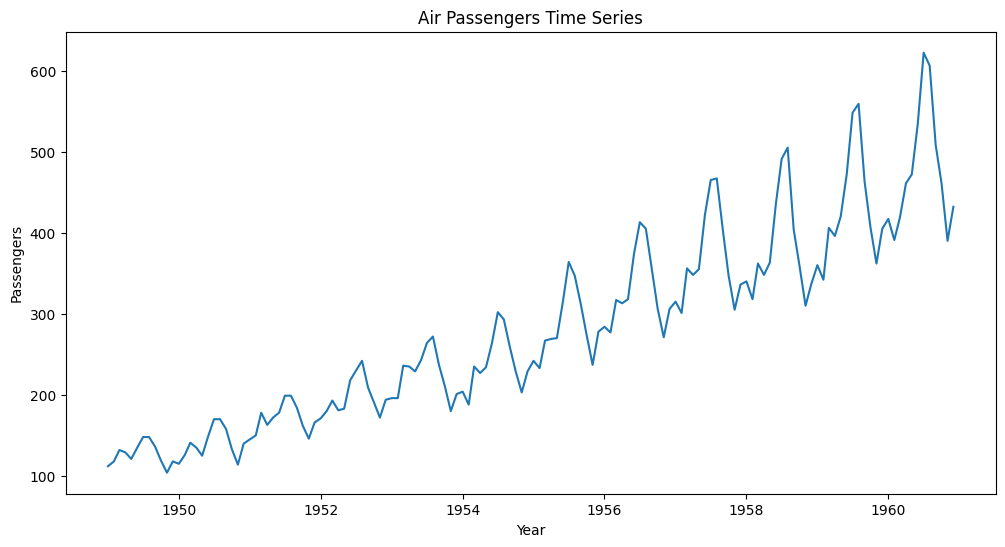

In [218]:
plt.figure(figsize=(12,6))
plt.plot(df["ds"], df["y"])
plt.title("Air Passengers Time Series")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.show()

## Train-Test Split
 - Forecasting the next 12 months.

In [219]:
train = df.iloc[:-12].copy()
test = df.iloc[-12:].copy()

## Linear Regression Baseline

In [220]:
def create_lags(data, lags=12):
    df = data.copy()
    for i in range(1, lags + 1):
        df[f"lag_{i}"] = df["y"].shift(i)
    return df.dropna()

train_lagged = create_lags(train)


In [221]:
train_lagged

,ds,y,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12
12,1950-01-01,115,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0,132.0,118.0,112.0
13,1950-02-01,126,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0,132.0,118.0
14,1950-03-01,141,126.0,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0,132.0
15,1950-04-01,135,141.0,126.0,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0,129.0
16,1950-05-01,125,135.0,141.0,126.0,115.0,118.0,104.0,119.0,136.0,148.0,148.0,135.0,121.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,1959-08-01,559,548.0,472.0,420.0,396.0,406.0,342.0,360.0,337.0,310.0,359.0,404.0,505.0
128,1959-09-01,463,559.0,548.0,472.0,420.0,396.0,406.0,342.0,360.0,337.0,310.0,359.0,404.0
129,1959-10-01,407,463.0,559.0,548.0,472.0,420.0,396.0,406.0,342.0,360.0,337.0,310.0,359.0
130,1959-11-01,362,407.0,463.0,559.0,548.0,472.0,420.0,396.0,406.0,342.0,360.0,337.0,310.0


In [222]:
from sklearn.linear_model import LinearRegression

X_train = train_lagged.drop(["ds","y"], axis=1)
y_train = train_lagged["y"]

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [223]:
len(X_train), len(y_train)

(120, 120)

## XGBoost Model

In [224]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=300)
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

### TimeGPT- Implementation
   step 1: Get your API Key

In [225]:
# Get your API Key at dashboard.nixtla.
from nixtla import NixtlaClient
from google.colab import userdata

# 1. Instantiate the NixtlaClient
# Assuming you have stored your Nixtla API key in Colab secrets under the name 'NI_API_KEY'
NI_API_KEY = userdata.get('NIXTLA_API_KEY')
nixtla_client = NixtlaClient(NI_API_KEY)


# 3. Forecast for the next 12 months
forecast_df = nixtla_client.forecast(
    df=train,    # 2. Read the data
    h=12,
    time_col="ds",
    target_col="y"
)


In [226]:
forecast_df.head()

,ds,TimeGPT
0,1960-01-01,414.51428
1,1960-02-01,403.24426
2,1960-03-01,443.12720
3,1960-04-01,439.75092
4,1960-05-01,462.83655


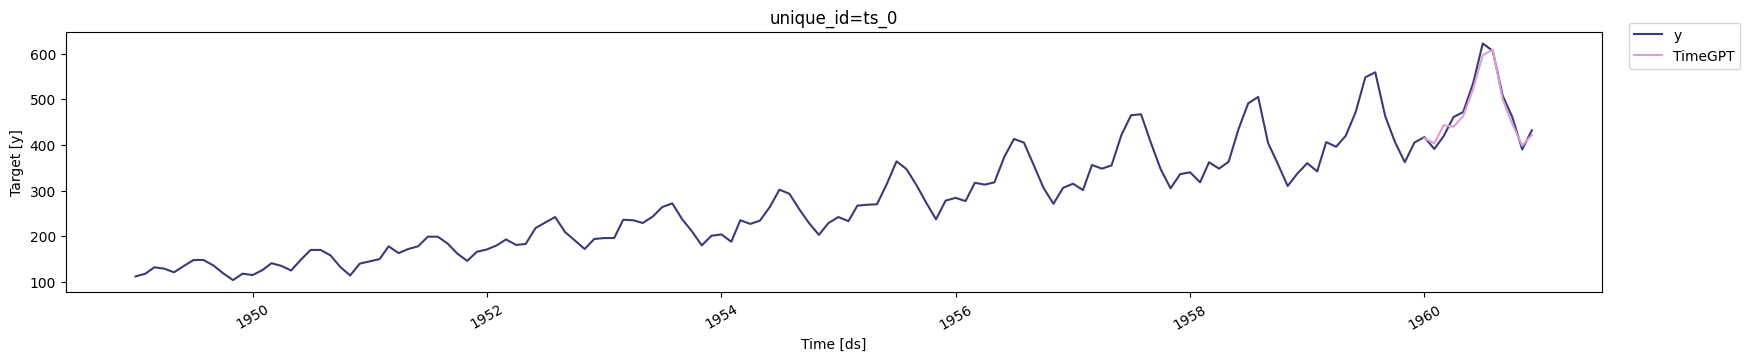

In [227]:
# plot the results
nixtla_client.plot(df, forecast_df)

## Generate Predictions for Linear Regression AND xGBOOST

In [228]:
def direct_forecast(models, train_df, lags=12):
    history = train_df.copy()
    temp = history.copy()

    # Create lag features
    for i in range(1, lags + 1):
        temp[f"lag_{i}"] = temp["y"].shift(i)

    last_row = temp.dropna().iloc[-1:]
    X_last = last_row.drop(["ds","y"], axis=1)

    predictions = []

    for model in models:
        pred = model.predict(X_last)[0]
        predictions.append(pred)

    return predictions

## Evaluation Metrics

In [229]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

In [230]:
tgpt_pred = forecast_df["TimeGPT"].values
print(len(test))
print(len(tgpt_pred))

12
12


In [231]:
# Linear Regression
lr_mae, lr_rmse, lr_mape = evaluate(test["y"], lr_pred)

# XGBoost
xgb_mae, xgb_rmse, xgb_mape = evaluate(test["y"], xgb_pred)

# TimeGPT (if forecast is precomputed CSV)
tgpt_mae, tgpt_rmse, tgpt_mape = evaluate(test["y"], tgpt_pred)

ValueError: Found input variables with inconsistent numbers of samples: [12, 24]

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost", "TimeGPT"],
    "MAE": [lr_mae, xgb_mae, tgpt_mae],
    "RMSE": [lr_rmse, xgb_rmse, tgpt_rmse],
    "MAPE": [lr_mape, xgb_mape, tgpt_mape]
})

results

In [ ]:
import matplotlib.pyplot as plt

# Convert 'ds' columns to datetime objects before plotting
test['ds'] = pd.to_datetime(test['ds'])
forecast_df['ds'] = pd.to_datetime(forecast_df['ds'])

plt.figure(figsize=(12,6))
plt.plot(test["ds"], test["y"], label="Actual")
plt.plot(test["ds"], lr_pred, label="Linear Regression")
plt.plot(test["ds"], xgb_pred, label="XGBoost")
plt.plot(forecast_df["ds"], tgpt_pred, label="TimeGPT")
plt.legend()
plt.title("Forecast Comparison")
plt.show()

## Compare Results

# Task
Create a function to prepare the lagged features for the entire test set (12 months) directly. This function will use the historical 'y' values from the training set and the actual 'y' values from the test set (if available for earlier steps in the test set) to construct the lag features for each step in the test set. This ensures that predictions for each test point are made without feeding back previous predictions. Then, apply this function to generate the feature matrix (X_test) for the test set, and use the trained Linear Regression and XGBoost models (`lr` and `xgb`) to generate predictions for all 12 months of the test set, storing them in `lr_pred` and `xgb_pred` respectively. Re-calculate the Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE) for Linear Regression and XGBoost using their new direct forecasts (`lr_pred` and `xgb_pred`) against the actual values in `test['y']`, keeping TimeGPT metrics as previously calculated. Finally, generate a plot comparing the actual values from the `test` set with the direct forecasts from Linear Regression, XGBoost, and the TimeGPT forecast, ensuring it is clearly labeled with a title, axis labels, and a legend for all series.

## Prepare Direct Forecast Features

### Subtask:
Create a function to prepare the lagged features for the entire test set (12 months) directly. This function will use the historical 'y' values from the training set and the actual 'y' values from the test set (if available for earlier steps in the test set) to construct the lag features for each step in the test set. This ensures that predictions for each test point are made without feeding back previous predictions.


**Reasoning**:
The subtask requires defining a function `create_direct_lagged_features` to generate lagged features for the test set. This function will create lag features for the combined dataframe and then extract the relevant features for the test set starting from `test_start_index`, dropping 'ds' and 'y' columns.



In [232]:
def create_direct_lagged_features(df_combined, test_start_index, lags=12):
    df = df_combined.copy()
    for i in range(1, lags + 1):
        df[f"lag_{i}"] = df["y"].shift(i)

    # Select only the test set rows
    test_features = df.iloc[test_start_index:]

    # Drop 'ds' and 'y' to create X_test
    X_test = test_features.drop(["ds", "y"], axis=1)
    return X_test

**Reasoning**:
Now that the `create_direct_lagged_features` function is defined, it needs to be called to generate the feature matrix (`X_test`) for the test set. This involves combining the training and test data, identifying the start index of the test set, and then applying the function. After obtaining `X_test`, predictions for Linear Regression (`lr_pred`) and XGBoost (`xgb_pred`) can be generated using their respective trained models.



In [233]:
df_combined = pd.concat([train, test], ignore_index=True)
test_start_index = len(train)

X_test = create_direct_lagged_features(df_combined, test_start_index)

lr_pred = lr.predict(X_test)
xgb_pred = xgb.predict(X_test)

print("Linear Regression predictions generated.")
print("XGBoost predictions generated.")

Linear Regression predictions generated.
XGBoost predictions generated.


**Reasoning**:
With the `lr_pred` and `xgb_pred` now correctly generated for the test set, the next step is to re-calculate their evaluation metrics (MAE, RMSE, MAPE) against the actual `test['y']` values. The `tgpt_pred` metrics will remain the same as they were already correctly computed.



In [234]:
lr_mae, lr_rmse, lr_mape = evaluate(test["y"], lr_pred)
xgb_mae, xgb_rmse, xgb_mape = evaluate(test["y"], xgb_pred)

results = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost", "TimeGPT"],
    "MAE": [lr_mae, xgb_mae, tgpt_mae],
    "RMSE": [lr_rmse, xgb_rmse, tgpt_rmse],
    "MAPE": [lr_mape, xgb_mape, tgpt_mape]
})

results

,Model,MAE,RMSE,MAPE
0,Linear Regression,17.193028,20.761455,3.751135
1,XGBoost,24.595320,31.110395,5.078328
2,TimeGPT,58.103068,63.562675,12.570361
